In [11]:
import sys
import pandas as pd

print("Ścieżka interpretera:", sys.executable)
print("Wersja Pythona:", sys.version)
print("Wersja pandas:", pd.__version__)
### Ile zamówień mieliśmy w sześciu dniach?
import pandas as pd
from pathlib import Path

# Sprawdzamy ścieżkę do pliku, żeby na pewno go znalazło
sciezka = Path("../data/raw/orders_intro.csv") if Path("../data/raw/orders_intro.csv").exists() else Path("data/raw/orders_intro.csv")

df = pd.read_csv(sciezka)
df
# Znajdujemy kolumnę z liczbami
kolumna = [c for c in df.columns if df[c].dtype in ['int64', 'float64']][-1]

tabela_wynikow = pd.DataFrame({
    "Liczba dni": [df[kolumna].count()],
    "Suma": [df[kolumna].sum()],
    "Średnia": [df[kolumna].mean()],
    "Mediana": [df[kolumna].median()]
})

tabela_wynikow

Ścieżka interpretera: c:\Users\Lenovo\Desktop\praktyki dane\.venv\Scripts\python.exe
Wersja Pythona: 3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]
Wersja pandas: 3.0.6


,Liczba dni,Suma,Średnia,Mediana
0,6,120,20.0,11.0


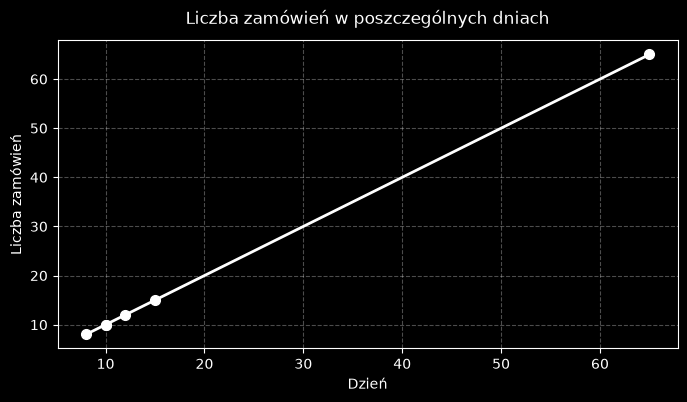

In [14]:
import matplotlib.pyplot as plt

# Pobieramy kolumny: data/dzień i zamówienia
kolumna_dni = df.columns[0]
kolumna_zamowienia = [c for c in df.columns if df[c].dtype in ['int64', 'float64']][-1]

fig, ax = plt.subplots(figsize=(8, 4), facecolor='black')
ax.set_facecolor('black')

ax.plot(df[kolumna_dni], df[kolumna_zamowienia], marker='o', color='white', linewidth=2, markersize=7)
ax.set_title('Liczba zamówień w poszczególnych dniach', color='white', pad=12)
ax.set_xlabel('Dzień', color='white')
ax.set_ylabel('Liczba zamówień', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')

ax.grid(True, linestyle='--', alpha=0.3, color='white')
plt.show()


In [13]:
# Wariant 1: Wszystkie 6 obserwacji
wariant_wszystkie = df[kolumna_zamowienia]

# Wariant 2: 5 obserwacji bez wartości 65
wariant_bez_65 = df[df[kolumna_zamowienia] != 65][kolumna_zamowienia]

# Tabela porównawcza
porownanie_df = pd.DataFrame({
    'Metryka': ['Minimum', 'Maksimum', 'Średnia', 'Mediana'],
    'Wszystkie (6 liczb)': [
        wariant_wszystkie.min(),
        wariant_wszystkie.max(),
        wariant_wszystkie.mean(),
        wariant_wszystkie.median()
    ],
    'Bez 65 (5 liczb)': [
        wariant_bez_65.min(),
        wariant_bez_65.max(),
        wariant_bez_65.mean(),
        wariant_bez_65.median()
    ]
})

porownanie_df


,Metryka,Wszystkie (6 liczb),Bez 65 (5 liczb)
0,Minimum,8.0,8.0
1,Maksimum,65.0,15.0
2,Średnia,20.0,11.0
3,Mediana,11.0,10.0


Usunięcie wartości 65 spowodowało drastyczny spadek średniej (z 20 do 11), podczas gdy mediana zmieniła się jedynie nieznacznie (z 11 do 10), co pokazuje, że mediana jest znacznie bardziej odporna na obserwacje odstające. Taka pojedyncza, mocno wyróżniająca się wartość nie dowodzi automatycznie błędu w danych, ponieważ może wynikać z realnego zjawiska biznesowego, takiego jak jednorazowa akcja marketingowa, duża promocja czy nagły wzrost sprzedaży w weekend. W analizie danych taką nietypową wartość nazywamy obserwacją odstającą (ang. outlier) i przed jej ewentualnym usunięciem należy zawsze sprawdzić kontekst biznesowy.